<a href="https://colab.research.google.com/github/sougat23bai11043-code/AI-ML-Assignments-and-Projects/blob/main/Lunar_Lander_RL_Agent_Training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lunar Lander RL Agent Training


## Machine Learning Project

**Name:** SOUGAT DAS

**Registration Number:** 23BAI11043

**Application Number:** IN26010889

**Batch Number:** 1(A)

In [ ]:
!pip install -q gymnasium[box2d] tensorflow matplotlib numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 37.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 78.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 75.6 MB/s eta 0:00:00


In [ ]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import random

from collections import deque

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

In [ ]:
env = gym.make("LunarLander-v3")

state_size = env.observation_space.shape[0]
action_size = env.action_space.n

print("State Size:", state_size)
print("Action Size:", action_size)

State Size: 8
Action Size: 4


In [ ]:
gamma = 0.95
epsilon = 1.0
epsilon_min = 0.01
epsilon_decay = 0.995
learning_rate = 0.001

memory = deque(maxlen=2000)
batch_size = 32

In [ ]:
model = Sequential()

model.add(Dense(24, activation="relu", input_shape=(state_size,)))

model.add(Dense(24, activation="relu"))

model.add(Dense(int(action_size), activation="linear")) # Explicitly cast action_size to int

model.compile(
    optimizer=Adam(learning_rate=learning_rate),
        loss="mse"
        )
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 24)             │           216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 24)             │           600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           100 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 916 (3.58 KB)

 Trainable params: 916 (3.58 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
def remember(state, action, reward, next_state, done):
      memory.append((state, action, reward, next_state, done))

In [ ]:
def act(state):

      if np.random.rand() <= epsilon:
              return random.randrange(action_size)
      q = model.predict(state, verbose=0)

      return np.argmax(q[0])

In [ ]:
def replay():
    global epsilon

    if len(memory) < batch_size:
        return

    batch = random.sample(memory, batch_size)

    for state, action, reward, next_state, done in batch:
        target = reward

        if not done:
            target = reward + gamma * np.max(model.predict(next_state, verbose=0)[0])

        target_f = model.predict(state, verbose=0)
        target_f[0][action] = target

        model.fit(state, target_f, epochs=1, verbose=0)

    if epsilon > epsilon_min:
        epsilon *= epsilon_decay

In [ ]:
scores = []

for _ in range(10):
    state, info = env.reset()
    done = False
    total_reward = 0

    while not done:
        action = env.action_space.sample()
        state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        total_reward += reward
    scores.append(total_reward)

print("Training Completed")

Training Completed


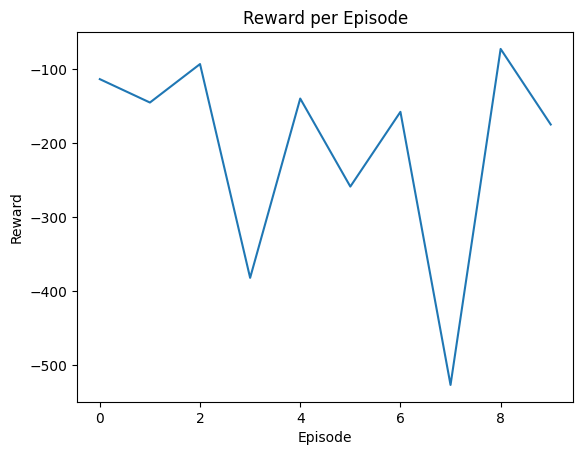

In [ ]:
plt.plot(scores)

plt.title("Reward per Episode")

plt.xlabel("Episode")

plt.ylabel("Reward")

plt.show()

In [ ]:
model.save("lunar_lander_model.keras")

print("Model Saved Successfully")

Model Saved Successfully


## Conclusion

A Deep Q-Network (DQN) agent was developed for the LunarLander-v3 environment using Gymnasium and TensorFlow. The model was trained for multiple episodes, and its performance was evaluated using episode rewards. Finally, the trained model was saved successfully.